EDA

In [56]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_rows", None)
data = pd.read_csv('train.csv')
df = pd.DataFrame(data)
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 2051 entries, 0 to 2050
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               2051 non-null   int64  
 1   PID              2051 non-null   int64  
 2   MS SubClass      2051 non-null   int64  
 3   MS Zoning        2051 non-null   str    
 4   Lot Frontage     1721 non-null   float64
 5   Lot Area         2051 non-null   int64  
 6   Street           2051 non-null   str    
 7   Alley            140 non-null    str    
 8   Lot Shape        2051 non-null   str    
 9   Land Contour     2051 non-null   str    
 10  Utilities        2051 non-null   str    
 11  Lot Config       2051 non-null   str    
 12  Land Slope       2051 non-null   str    
 13  Neighborhood     2051 non-null   str    
 14  Condition 1      2051 non-null   str    
 15  Condition 2      2051 non-null   str    
 16  Bldg Type        2051 non-null   str    
 17  House Style      2051 non

In [22]:
print(df.isnull().sum().to_string())

Id                    0
PID                   0
MS SubClass           0
MS Zoning             0
Lot Frontage        330
Lot Area              0
Street                0
Alley              1911
Lot Shape             0
Land Contour          0
Utilities             0
Lot Config            0
Land Slope            0
Neighborhood          0
Condition 1           0
Condition 2           0
Bldg Type             0
House Style           0
Overall Qual          0
Overall Cond          0
Year Built            0
Year Remod/Add        0
Roof Style            0
Roof Matl             0
Exterior 1st          0
Exterior 2nd          0
Mas Vnr Type       1240
Mas Vnr Area         22
Exter Qual            0
Exter Cond            0
Foundation            0
Bsmt Qual            55
Bsmt Cond            55
Bsmt Exposure        58
BsmtFin Type 1       55
BsmtFin SF 1          1
BsmtFin Type 2       56
BsmtFin SF 2          1
Bsmt Unf SF           1
Total Bsmt SF         1
Heating               0
Heating QC      

In [21]:
missing = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percent': (df.isnull().sum()/ len(df) * 100).round(2)
})
missing = missing.sort_values('Percent', ascending=False)
print(missing)
#                  Missing   Percent
# Pool QC             2042    99.56
# Misc Feature        1986    96.83
# Alley               1911    93.17
# Fence               1651    80.50
# Mas Vnr Type        1240    60.46

                 Missing  Percent
Pool QC             2042    99.56
Misc Feature        1986    96.83
Alley               1911    93.17
Fence               1651    80.50
Mas Vnr Type        1240    60.46
Fireplace Qu        1000    48.76
Lot Frontage         330    16.09
Garage Cond          114     5.56
Garage Yr Blt        114     5.56
Garage Finish        114     5.56
Garage Qual          114     5.56
Garage Type          113     5.51
Bsmt Exposure         58     2.83
BsmtFin Type 2        56     2.73
Bsmt Qual             55     2.68
Bsmt Cond             55     2.68
BsmtFin Type 1        55     2.68
Mas Vnr Area          22     1.07
Bsmt Full Bath         2     0.10
Bsmt Half Bath         2     0.10
BsmtFin SF 1           1     0.05
Garage Cars            1     0.05
Total Bsmt SF          1     0.05
Bsmt Unf SF            1     0.05
BsmtFin SF 2           1     0.05
Garage Area            1     0.05
Paved Drive            0     0.00
Full Bath              0     0.00
Half Bath     

Будем избавляться от тех признаков, где пропуски более 60%

In [49]:
print(df['SalePrice'].mean())

181469.70160897123


In [48]:
# features = [
#     'SalePrice',
#     'Lot Area',
#     'Neighborhood',
#     'Condition 1',
#     'Condition 2',
#     'Overall Qual',
#     'Overall Cond',
#     'Year Built',
#     'Year Remod/Add',
#     'Exter Qual',
#     'Exter Cond',
#     'Heating',
#     'Heating QC',
#     'Gr Liv Area',
#     'TotRms AbvGrd',
#     'Functional'
# ]

# df = df[features]
# df.hist(figsize=(20,20))

In [50]:
print('Lot area', df['Lot Area'].max())
print('Lot area', df['Lot Area'].mean())
print('gr liv area', df['Gr Liv Area'].mean())

Lot area 159000
Lot area 10065.20819112628
gr liv area 1499.330082886397


SalePrice         1.000000
Overall Qual      0.800207
Gr Liv Area       0.697038
Garage Area       0.650270
Garage Cars       0.648220
Total Bsmt SF     0.628925
1st Flr SF        0.618486
Year Built        0.571849
Year Remod/Add    0.550370
Full Bath         0.537969
Garage Yr Blt     0.533922
Mas Vnr Area      0.512230
TotRms AbvGrd     0.504014
Fireplaces        0.471093
BsmtFin SF 1      0.423519
Name: SalePrice, dtype: float64
Lot Frontage       0.341842
Open Porch SF      0.333476
Wood Deck SF       0.326490
Lot Area           0.296566
Bsmt Full Bath     0.283662
Half Bath          0.283001
2nd Flr SF         0.248452
Bsmt Unf SF        0.190210
Bedroom AbvGr      0.137067
Screen Porch       0.134581
3Ssn Porch         0.048732
Mo Sold            0.032735
Pool Area          0.023106
BsmtFin SF 2       0.016255
Misc Val          -0.007375
Yr Sold           -0.015203
Low Qual Fin SF   -0.041594
Bsmt Half Bath    -0.045328
Id                -0.051398
MS SubClass       -0.087335
Ove

<Axes: ylabel='SalePrice'>

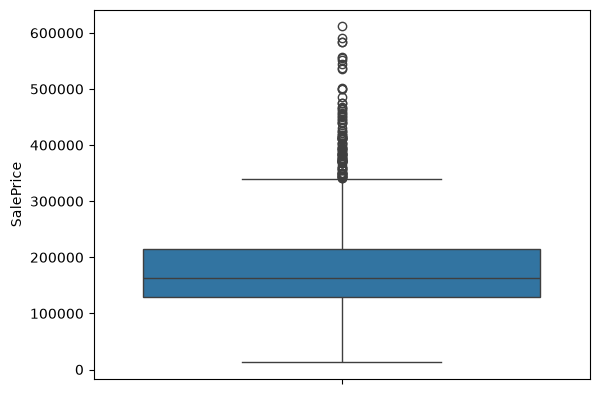

In [104]:
corr = df.corr(numeric_only=True)
sale = corr['SalePrice'].sort_values(ascending=False)
print(sale[sale > 0.4])
print(sale[sale < 0.4])
sns.boxplot(df["SalePrice"])



после первичного анализа я увидел, что некторое кол-во признаков имеют процент пропусков более 60. Так же довольно много признаков которые никак не влияют на цену дома. И увидел от чего сильнее всего зависит наша цена.

In [73]:
df[df['SalePrice'] > 400000]
df.describe()

,Id,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2051.000000,2.051000e+03,2051.000000,1721.000000,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000,2029.000000,...,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000
mean,1474.033642,7.135900e+08,57.008776,69.055200,10065.208191,6.112140,5.562165,1971.708922,1984.190151,99.695909,...,93.833740,47.556802,22.571916,2.591419,16.511458,2.397855,51.574354,6.219893,2007.775719,181469.701609
std,843.980841,1.886918e+08,42.824223,23.260653,6742.488909,1.426271,1.104497,30.177889,21.036250,174.963129,...,128.549416,66.747241,59.845110,25.229615,57.374204,37.782570,573.393985,2.744736,1.312014,79258.659352
min,1.000000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,753.500000,5.284581e+08,20.000000,58.000000,7500.000000,5.000000,5.000000,1953.500000,1964.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129825.000000
50%,1486.000000,5.354532e+08,50.000000,68.000000,9430.000000,6.000000,5.000000,1974.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,162500.000000
75%,2198.000000,9.071801e+08,70.000000,80.000000,11513.500000,7.000000,6.000000,2001.000000,2004.000000,161.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2930.000000,9.241520e+08,190.000000,313.000000,159000.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,547.000000,432.000000,508.000000,490.000000,800.000000,17000.000000,12.000000,2010.000000,611657.000000


Дорогие дома не являтся аномалией, следовательно, будем что-то делать с этими ценами. Потому что без обработки высокие ценники плохо скажутся на предикте нашей модели.


Общий вывод: под удаление идут следубщие столбцы с их пропусками и процентным соотношением:
Pool QC             2042    99.56
Misc Feature        1986    96.83
Alley               1911    93.17
Fence               1651    80.50
Mas Vnr Type        1240    60.46
Fireplace Qu        1000    48.76
Были выявлены признаки с большим количеством пропусков (PoolQC, Alley, Fence, FireplaceQu и др.). Перед удалением будет проведен анализ, являются ли пропуски отсутствием объекта или отсутствием информации.
Выбросы по цене были исследованы. Они соответствуют действительно дорогим объектам недвижимости и не являются ошибками данных.
Наиболее сильную корреляцию с ценой имеют OverallQual, GrLivArea, GarageArea, GarageCars и TotalBsmtSF.
В качестве базовой модели будет использована линейная регрессия, после чего результаты будут сравнены с Random Forest и XGBoost.
На следующем этапе будет выполнена предобработка данных и исследование возможности создания новых признаков (Feature Engineering).

In [114]:
print(df['SalePrice'].median())
print(df['SalePrice'].mean())

162500.0
181469.70160897123
